# House Price Prediction Model

### Objective
Build a model to predict residential house prices in the US using property and location features 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import joblib
import streamlit as st

In [2]:
df = pd.read_csv(r"C:\Users\Timi\Downloads\Data Analysis, SQL and ML Personal projects\HOUSING IN THE US DATA ANALYSIS AND PRICE PREDICTION MODEL\realtor-data.zip.csv")

## Dataset Overview

- Number of Observations: ~2.2M
- Features: House_size, State, City, Acre_lot, Bath, Bed
- Engineered features: sqft_per_bed, sqft_lot, price_per_acre, house_size_per_sqft
- Target: Price

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


# Data Cleaning

In [4]:
def wrangle(data):
    
    # Reading file into the dataframe
    df = pd.read_csv(data)
    
    # Selecting the features for our analysis and dropping columns  we won't be needing
    df = df[["price", "bed", "bath", "acre_lot", "city", "state", "house_size"]]
       
    # Analysing our bed and bath features which are very vital for our model development, we realise that we have a lot of observation (~471,000) where both bed and bath values are null.
    # And only about 9,500 where bed is null but bath still has some values.
    # We will be retaining the bath values with null bed values because the ratio compared to the total number of values for the bath feature is really low, so our simple imputer can work
    # with it during model developement.
    
    # Removing every observation where both the bath and bed values are null
    df = df[~(df[["bed", "bath"]].isnull().all(axis=1))][["price", "bed", "bath", "house_size", "acre_lot", "city", "state"]]
    
    # Dropping observations where acre_lot, bath and house_size feature values are missing
    df = df[~(df["acre_lot"].isnull() & df["bath"].isnull() & df["house_size"].isnull())]
    
    # Dropping observations where acre_lot, bed and house_size feature values are null
    df = df[~(df["acre_lot"].isnull() & df["bed"].isnull() & df["house_size"].isnull())]
    
    # Dropping observations where price, bath and acre_lot feature values are null
    df = df[~(df[["price", "bath", "acre_lot"]].isnull().all(axis=1))]
    
    # Dropping observations where price, bed, and acre_lot feature values are null
    df = df[~(df[["price", "bed", "acre_lot"]].isnull().all(axis=1))]
    
    # Dropping observations where both price and house_size values are null
    df = df[~(df[["price", "house_size"]].isnull().all(axis=1))]
    
    # Dropping all observations where price is null
    df = df[~(df["price"].isnull())]
    
    # Masking our price feature and taking out outliers
    low = df["price"].quantile(0.01)
    high = df["price"].quantile(0.97)
    df = df[df["price"].between(low, high)]
    
    # Dropping all observation where house_size feature value is null
    df = df[~(df["house_size"].isnull())]
    
    # Masking our house_size feature to fit our objective (residential houses)
    df = df[(df["house_size"] >= 200) & (df["house_size"] <= 50_000)]
    
    # Dropping observations with bed feature value of 444 (the highest number of bedrooms) because they have house_sizes of 1700 which is completely unrealistic
    df = df[~(df["bed"] == 444)]
    
    # Dropping observation with bed features value od 212 (the second highest number of bedrooms) because they have house_sizes of 5908 which is completely unrealistic
    df = df[~(df["bed"] == 212)]
    
    # Drop all null values for the bed feature
    # df = df[~df["bed"].isnull()]
    
    # Engineering sqft_per_bed feature
    df["sqft_per_bed"] = df["house_size"]/df["bed"]
    
    # Setting the limit of our sqft_per_bed feature
    df = df[df["sqft_per_bed"].between(80, 800)]
    
    # Removing extreme outliers for our acre_lot feature
    df = df[df["acre_lot"] <= 1_000]
    
    # Removing zero values for acre_lot feature
    df = df[~(df["acre_lot"] == 0)]
    
    # Engineering our price_per_acre feature
    df["price_per_acre"] = df["price"] / df["acre_lot"]

    # Converting the acre_lot feature to sqft
    df["sqft_lot"] = df["acre_lot"] * 43560
    
    # Dropping obeservations where the ratio of house size to sqft _lot is greater than 3 meaning we are setting the cap for our residential properties to 3 storey buildings
    df["house_size_per_sqft"] = df["house_size"] / df["sqft_lot"]
    df = df[(df["house_size_per_sqft"] <= 3) & (df["house_size_per_sqft"] > 0.001)]
    
    # Dropping all 0.01 value for our acre_lot feature
    df = df[df["acre_lot"] >= 0.02]
    
    # Dropping all observations where the bath and city values are null
    df = df[~(df[["bath", "city"]].isnull().all(axis=1))]
    
    #Creating a bath_per_bed feature to filter out houses with unrealistic bath to bed ratio
    df["bath_per_bed"] = df["bath"] / df["bed"]
    
    #Filtering out observations where our bath_per_bed is lower than 0.2 and greater than 3, this means that the minimum we are haing is 1 bath for 5 beds and the maximum is 3 bath for one bedroom
    df = df[df["bath_per_bed"].between(0.2, 3)]
    
    #Removing observations where our number of bedrooms is greater than 30 and house size <= 10000
    # df = df[~((df["bed"] > 30) & (df["house_size"] <= 10000))]
    
    # Resetting index at the end of every code run
    df = df.reset_index()
    df.drop(columns="index", inplace=True)
    
    #Dropping specific rows I've analysed to be unrealistic based on the number of beds to house size ratio, for instance, a house size of 4k sqft having 54 rooms is very very unrealistic.
    # df.drop(index=[127573, 566125, 467718, 320890, 833334, 321258, 168681, 499563, 500253, 502020, 503756, 505827, 508986, 519949, 523486, 561933, 388782], inplace=True)
    
    #Creating my price_per_sqft feature
    df["price_per_sqft"] = df["price"] / df["sqft_lot"]
    
    # log transforming features for model development
    df["house_size_log"] = np.log1p(df["house_size"])
    df["sqft_lot_log"] = np.log1p(df["sqft_lot"])
    df["bed_log"] = np.log1p(df["bed"])
    df["bath_log"] = np.log1p(df["bath"])
    df["price_log"] = np.log1p(df["price"])    
    
    return df

In [5]:
url = r"C:\Users\Timi\Downloads\Data Analysis, SQL and ML Personal projects\HOUSING IN THE US DATA ANALYSIS AND PRICE PREDICTION MODEL\realtor-data.zip.csv"
df = wrangle(url)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107456 entries, 0 to 1107455
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   price                1107456 non-null  float64
 1   bed                  1107456 non-null  float64
 2   bath                 1107456 non-null  float64
 3   house_size           1107456 non-null  float64
 4   acre_lot             1107456 non-null  float64
 5   city                 1107219 non-null  object 
 6   state                1107456 non-null  object 
 7   sqft_per_bed         1107456 non-null  float64
 8   price_per_acre       1107456 non-null  float64
 9   sqft_lot             1107456 non-null  float64
 10  house_size_per_sqft  1107456 non-null  float64
 11  bath_per_bed         1107456 non-null  float64
 12  price_per_sqft       1107456 non-null  float64
 13  house_size_log       1107456 non-null  float64
 14  sqft_lot_log         1107456 non-null  float64
 15

In [7]:
#   # Building my prediction model with numerical features alone
  
# features = ["house_size_log", "sqft_lot_log", "bed_log", "bath_log", "sqft_per_bed"]    
# X = df[features]

# target = "price_log"
# y = df[target]


# X_train, X_test, y_train, y_test = train_test_split(
        
#     X,
#     y,
        
#     test_size=0.2,
#     random_state=42
    
#     )
    
# y_mean = y_train.mean()
# y_pred_baseline = [y_mean] * len(X_train)
# y_pred_baseline[:5]

# baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
# print("baseline_mae = ", baseline_mae)

# model = LinearRegression()

# model.fit(X_train, y_train)

# y_pred_training = model.predict(X_train)

# training_mae = mean_absolute_error(y_train, y_pred_training)

# print("training_mae = ", training_mae)

# y_pred_test = model.predict(X_test)

# test_mae = mean_absolute_error(y_test, y_pred_test)
# print("test_mae = ", test_mae)

# np.exp(test_mae)

In [8]:
# Building my prediction model with both numerical and categorical features

features = ["house_size", "bed", "bath", "sqft_lot", "sqft_per_bed", "city", "state"]

target = "price"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size = 0.2,
    random_state=42
    
)

In [9]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(X_train)
y_pred_baseline[:5]

[np.float64(420963.7136700814),
 np.float64(420963.7136700814),
 np.float64(420963.7136700814),
 np.float64(420963.7136700814),
 np.float64(420963.7136700814)]

In [10]:
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
print("baseline_mae = ", baseline_mae)

baseline_mae =  214309.83156014944


In [11]:

log_features = ["house_size", "bed", "bath"]

other_num_features = ["sqft_lot", "sqft_per_bed"]

cat_features = ["city", "state"]

log_transformer = FunctionTransformer(
    np.log1p,
    validate=False
)

log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("log", log_pipeline, log_features),
    ("num", num_pipeline, other_num_features),
    ("cat", cat_pipeline, cat_features)
])

ridge = TransformedTargetRegressor(
    regressor = Ridge(),
    func=np.log1p,
    inverse_func=np.expm1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ridge)
])

model.fit(X_train, y_train)

y_pred_training = model.predict(X_train)
print("training_prediction = ", y_pred_training)

training_mae = mean_absolute_error(y_train, y_pred_training)
print("training_mae = ", training_mae)

y_pred_test = model.predict(X_test)
print("y_pred_test = ", y_pred_test)

test_mae = mean_absolute_error(y_test, y_pred_test)
print("test_mae = ", test_mae)


training_prediction =  [197435.89640631 512789.73421128 301913.59395902 ... 406639.0263316
 229961.68293518 358139.91230277]
training_mae =  92698.28398527308
y_pred_test =  [506658.69225116 384225.00182498 683029.48265336 ... 431277.51612043
 467566.95536134 241010.55235325]
test_mae =  93639.38300819024


In [12]:
r2 = r2_score(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)

print("r2 = ", r2)
print("rmse = ", rmse)

r2 =  0.7265935294869307
rmse =  157347.37285967523


In [13]:
joblib.dump(model, "House_price_model_2.pkl")

['House_price_model_2.pkl']

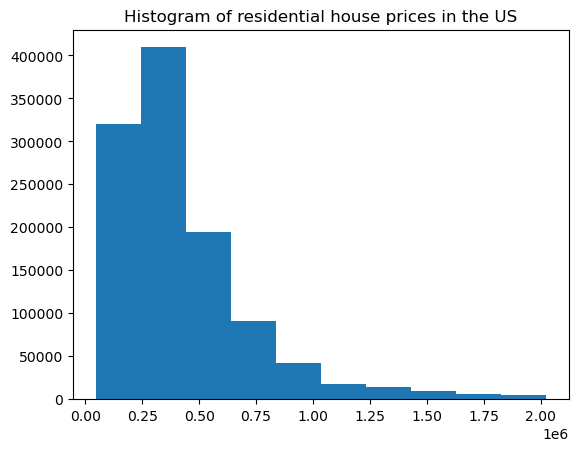

In [14]:
plt.hist(df["price"]);
plt.title("Histogram of residential house prices in the US");

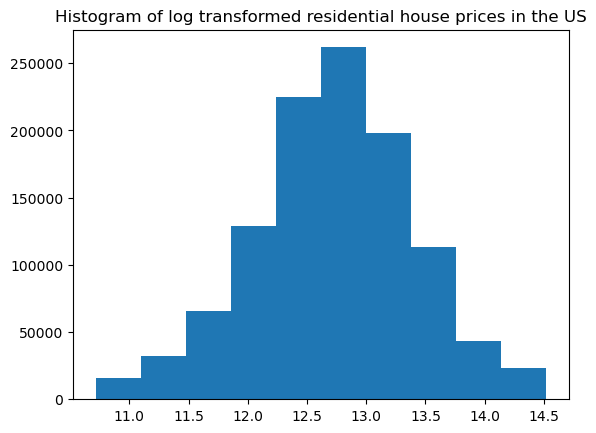

In [15]:
plt.hist(df["price_log"]);
plt.title("Histogram of log transformed residential house prices in the US");

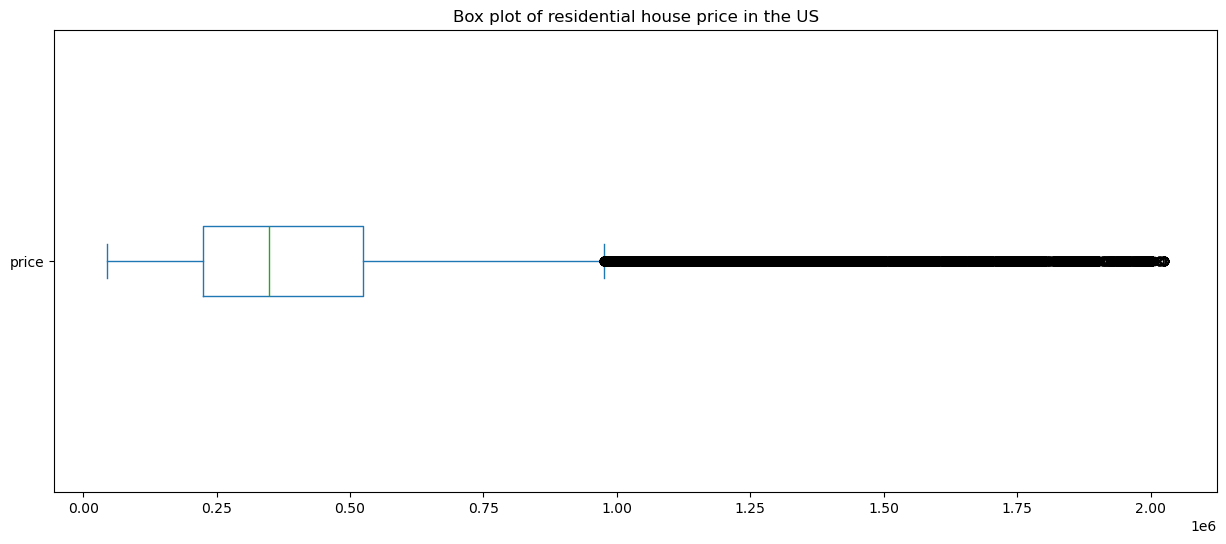

In [16]:
fig, ax = plt.subplots(figsize = (15, 6))
df["price"].plot(kind="box", vert=False)
plt.title("Box plot of residential house price in the US");

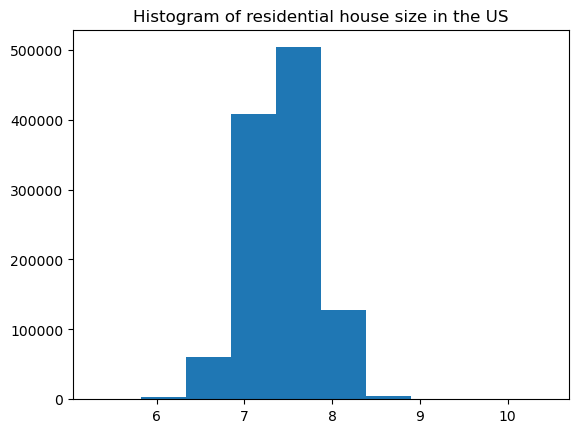

In [17]:
plt.hist(df["house_size_log"]);
plt.title("Histogram of residential house size in the US");

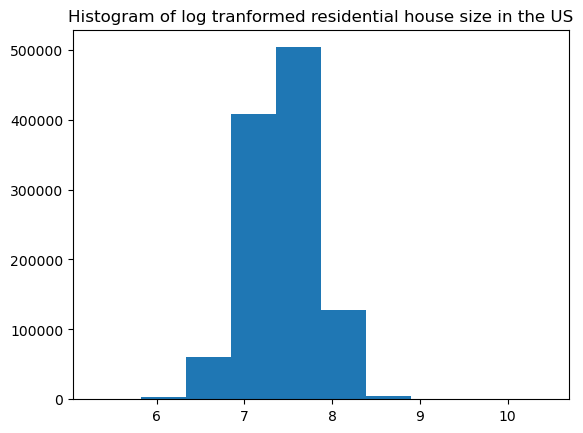

In [18]:
plt.hist(df["house_size_log"]);
plt.title("Histogram of log tranformed residential house size in the US");

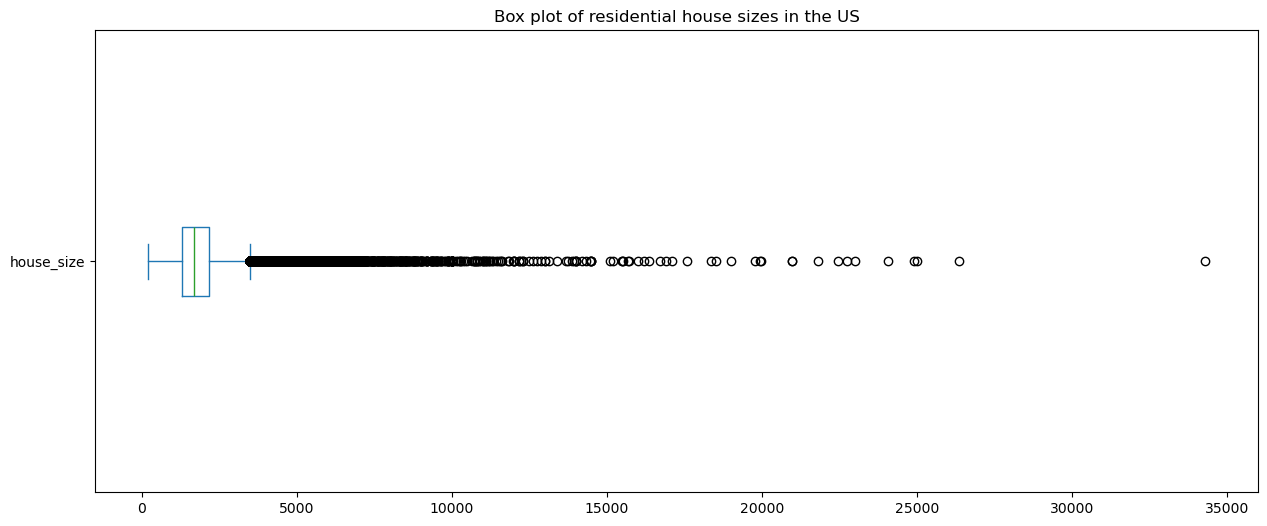

In [19]:
fig, ax = plt.subplots(figsize = (15, 6))
df["house_size"].plot(kind="box", vert=False,  ax=ax)
plt.title("Box plot of residential house sizes in the US");

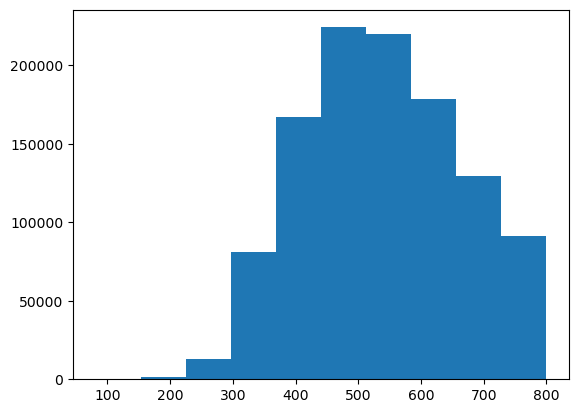

In [20]:
plt.hist(df["sqft_per_bed"]);

In [21]:
state_city = (
    df[["state", "city"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["state", "city"])
)

state_city.to_csv("state_city_lookup.csv", index=False)